# 06 — Explainability & Churn Drivers
**CRISP-DM Phase 5b: Model Interpretation**

Uses SHAP `TreeExplainer` for global and local explanations of the
LightGBM churn model trained in `04_modelling`.

| Section | Purpose |
|:--------|:--------|
| 1. Global Feature Importance | Mean \|SHAP\| bar + beeswarm — what drives churn across all customers |
| 2. Dependence Plots | Non-linear effect shapes for the top 3 features |
| 3. Local Explanations | Waterfall plots for highest-risk individuals — "why THIS customer?" |
| 4. SHAP-Based Segments | K-Means on SHAP values → data-driven retention segments |
| 5. Actionable Insights | Auto-generated segment profiles with recommended actions |

> **Note on interpretation**: SHAP explains the raw LightGBM log-odds, not the
> post-calibration probabilities. Feature directions are identical; only the
> magnitude scale differs from the calibrated scores used in production.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from churn.config import cfg
from churn.data.splitter import temporal_split
from churn.models.lgbm_model import EXCLUDE_COLS

# ── Executive visual theme (consistent with 04/05) ───────────────────────────
%matplotlib inline
shap.initjs()

ACCENT   = '#1565C0'
PASS_CLR = '#388E3C'
FAIL_CLR = '#D32F2F'
WARN_CLR = '#F57C00'
NEUTRAL  = '#546E7A'
sns.set_theme(style='white')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120})

print('Modules loaded.')

Modules loaded.


In [4]:
# ── Load model artefacts (joblib, not pkl) ────────────────────────────────────
artefacts = Path(cfg.paths.model_artefacts_dir)
model = joblib.load(artefacts / 'lgbm_model.joblib')

# ── Load ALL feature snapshots and temporal split (same as 04/05) ─────────────
features_dir = Path(cfg.paths.features_dir)
parquet_files = sorted(features_dir.glob('features_*.parquet'))
fm = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
split = temporal_split(fm)

X_test = split.X_test
y_test = split.y_test

# Feature columns for SHAP (exclude IDs, dates, raw categoricals)
feature_cols = [c for c in X_test.columns if c not in EXCLUDE_COLS]
X_feat = X_test[feature_cols]

# ── Compute SHAP values using TreeExplainer ───────────────────────────────────
MAX_SHAP_SAMPLES = 5_000
if len(X_feat) > MAX_SHAP_SAMPLES:
    X_shap = X_feat.sample(MAX_SHAP_SAMPLES, random_state=42)
    print(f'SHAP: sampled {MAX_SHAP_SAMPLES:,} of {len(X_feat):,} customers for speed')
else:
    X_shap = X_feat.copy()

explainer = shap.TreeExplainer(model.booster)
shap_values = explainer(X_shap)

# Figures directory
fig_dir = Path(cfg.paths.figures_dir)
fig_dir.mkdir(parents=True, exist_ok=True)

print(f'Test set: {X_test.shape[0]:,} customers × {len(feature_cols)} features')
print(f'SHAP values shape: {shap_values.values.shape}')

SHAP: sampled 5,000 of 200,806 customers for speed
Test set: 200,806 customers × 37 features
SHAP values shape: (5000, 37)


## 1. Global Feature Importance

Two complementary views:
- **Bar chart** — mean |SHAP| per feature: which features matter most *on average*
- **Beeswarm** — direction + magnitude: *how* each feature drives churn (red = high value, blue = low)

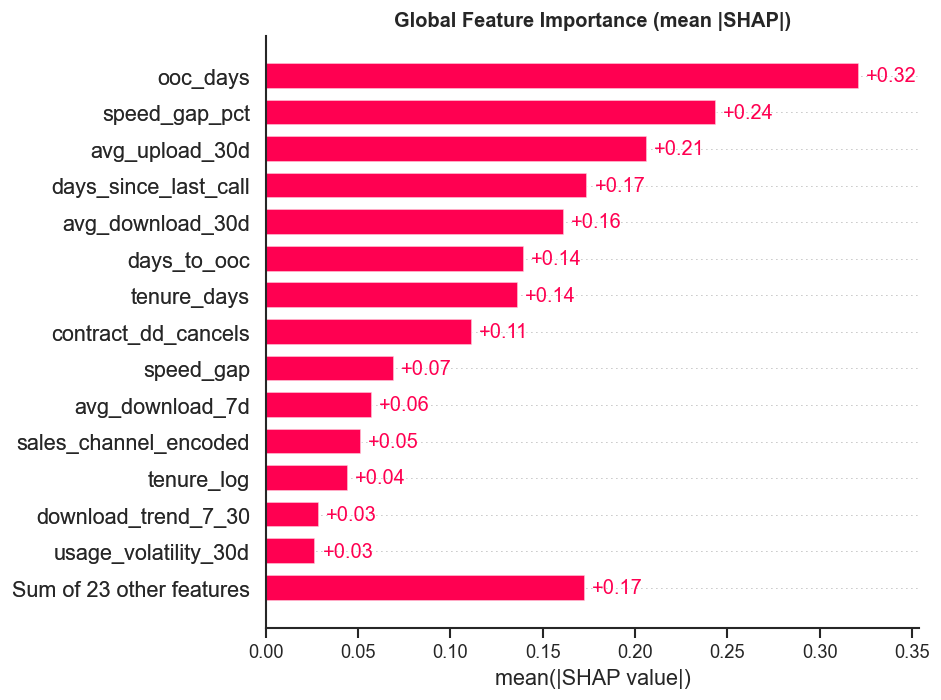

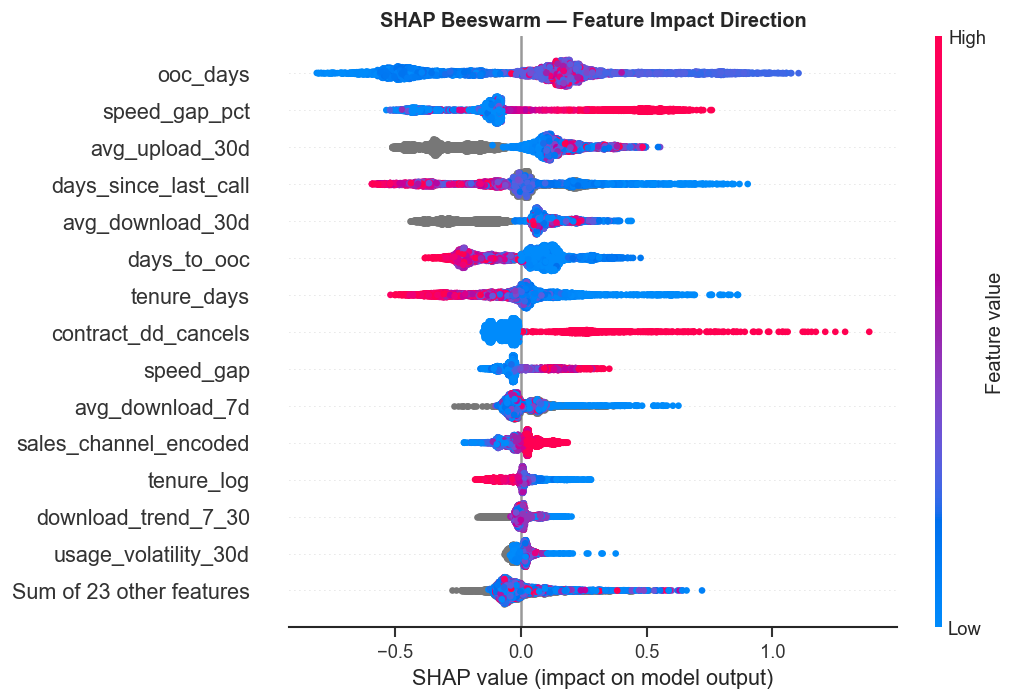

Saved → /Users/victoroko/Documents/tech-test/outputs/figures/shap_bar.png, /Users/victoroko/Documents/tech-test/outputs/figures/shap_beeswarm.png


In [5]:
# Panel 1: Mean |SHAP| bar chart
fig1, ax1 = plt.subplots(figsize=(8, 6))
shap.plots.bar(shap_values, max_display=15, show=False, ax=ax1)
ax1.set_title('Global Feature Importance (mean |SHAP|)', fontweight='bold')
plt.tight_layout()
fig1.savefig(fig_dir / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Panel 2: Beeswarm — direction + magnitude
# shap 0.50+ beeswarm doesn't support ax + plot_size together; use plot_size=None
fig2, ax2 = plt.subplots(figsize=(9, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False, ax=ax2, plot_size=None)
ax2.set_title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
fig2.savefig(fig_dir / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved → {fig_dir / "shap_bar.png"}, {fig_dir / "shap_beeswarm.png"}')

## 2. Dependence Plots — Top 3 Features

Reveals the **non-linear effect shape** for each top feature.  
For example, `ooc_days` may show a cliff-edge where churn risk jumps suddenly at contract expiry.

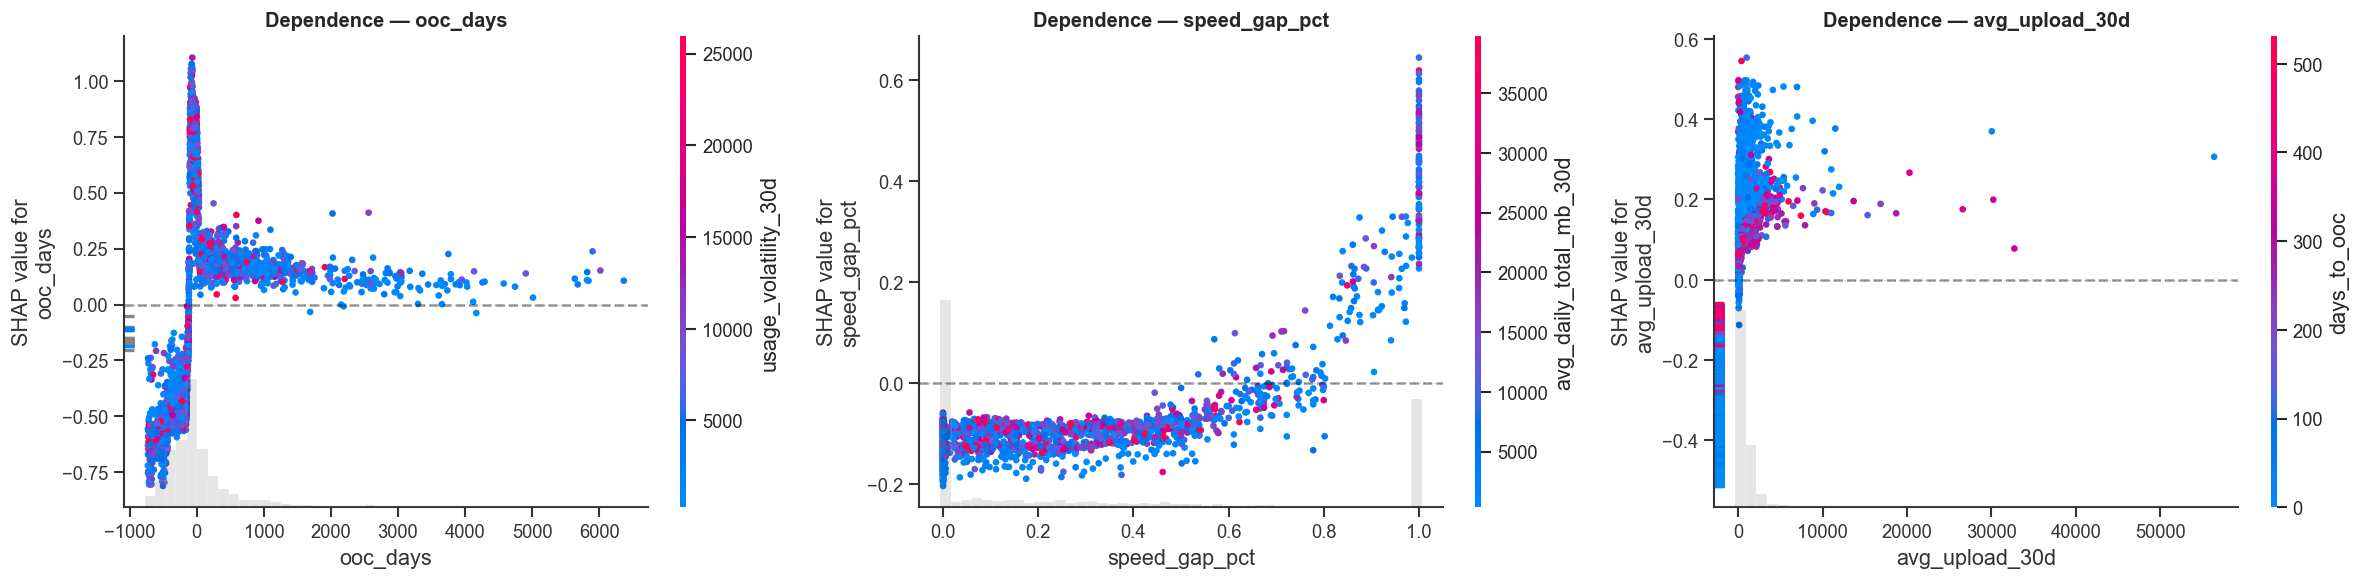

Top 3 features: ['ooc_days', 'speed_gap_pct', 'avg_upload_30d']


In [6]:
# Identify top 3 features by mean |SHAP|
mean_abs = np.abs(shap_values.values).mean(axis=0)
top3_idx = np.argsort(mean_abs)[::-1][:3]
top3_features = [X_shap.columns[i] for i in top3_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, feat_name, feat_idx in zip(axes, top3_features, top3_idx):
    shap.plots.scatter(
        shap_values[:, feat_idx],
        color=shap_values,
        show=False,
        ax=ax,
    )
    ax.set_title(f'Dependence — {feat_name}', fontweight='bold')
    ax.axhline(0, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
fig.savefig(fig_dir / 'shap_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top 3 features: {top3_features}')

## 3. Local Explanations — Individual Customer Waterfall

Answers: **"Why is THIS customer predicted to churn?"**

Waterfall plots show the base expected value plus each feature's additive contribution.
These are invaluable for retention agents — they see *why* a customer is flagged so they
can tailor the conversation.

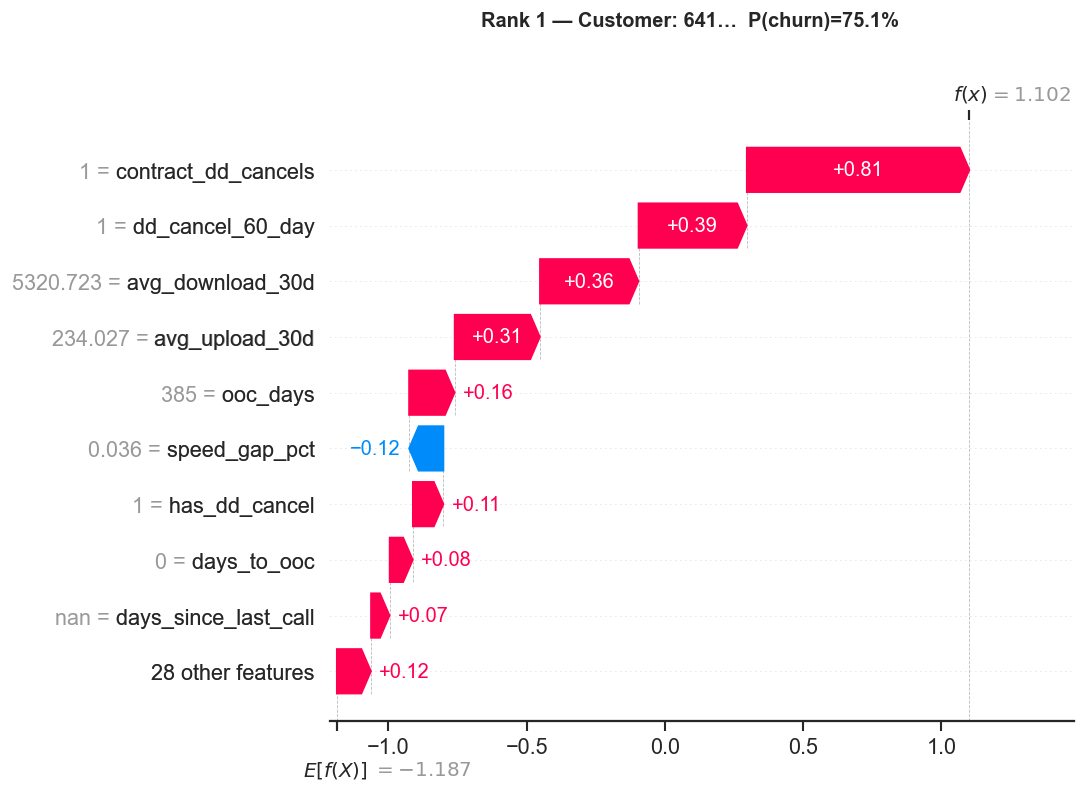

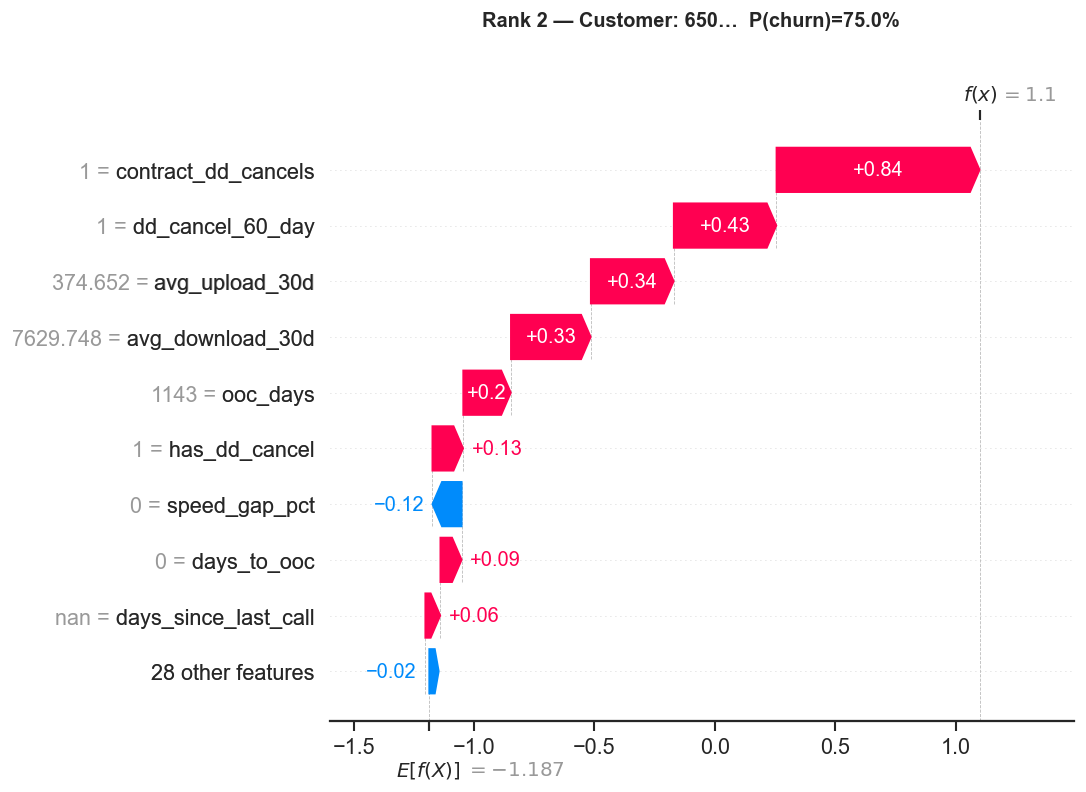

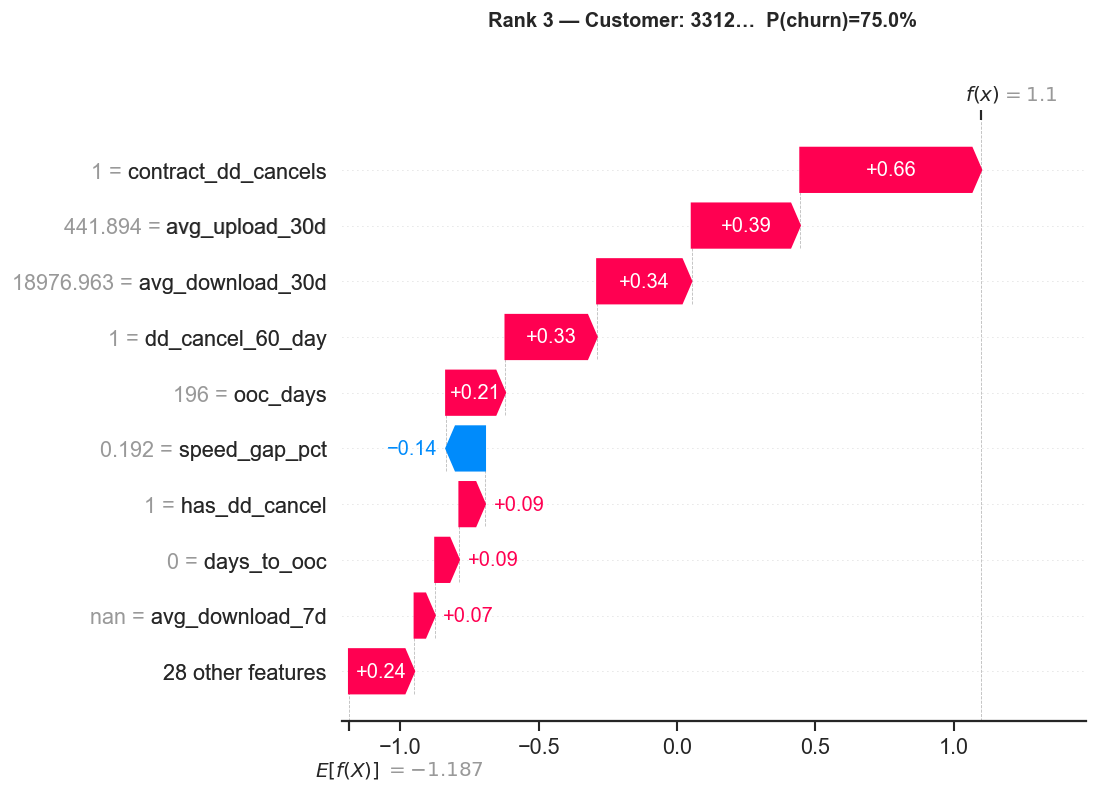

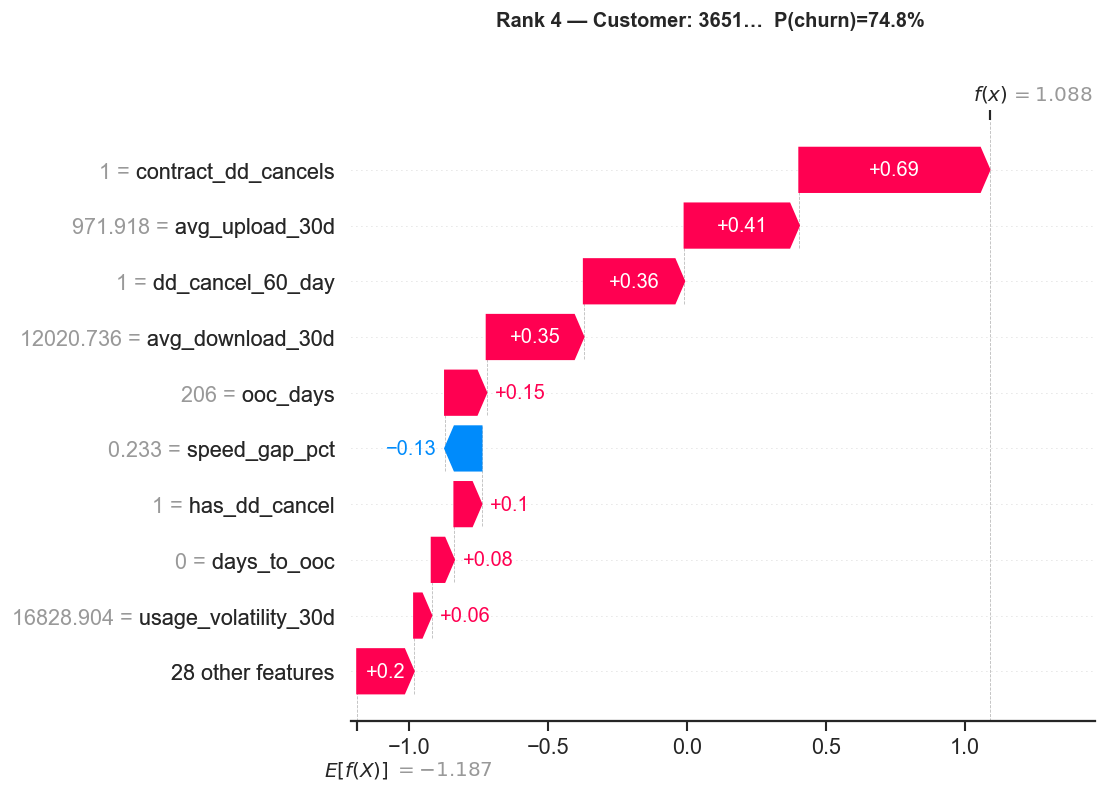

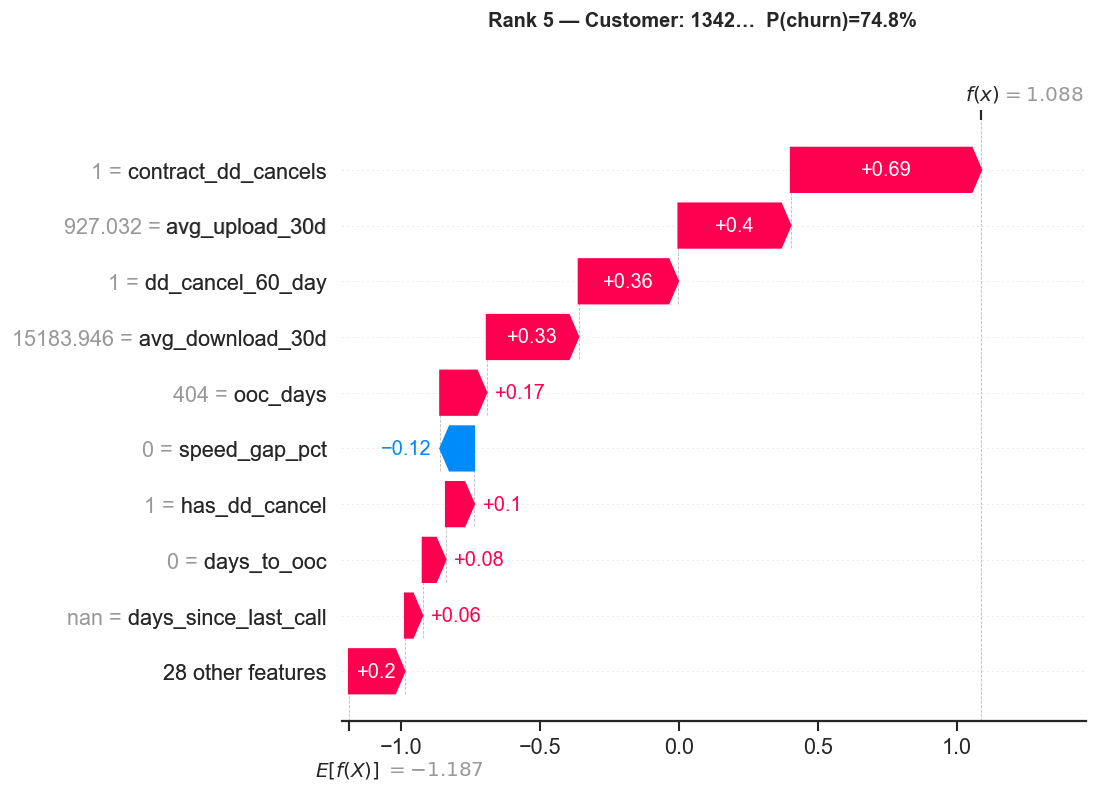

Waterfall plots saved for top 5 customers


In [7]:
# Get calibrated probabilities for the SHAP sample
proba_full = model.predict_proba(X_test)

# Map SHAP sample indices back to full test set to get probabilities
shap_sample_idx = X_shap.index
proba_shap = proba_full[X_test.index.get_indexer(shap_sample_idx)]

# Top 5 highest-risk in the SHAP sample
top5_local = np.argsort(proba_shap)[::-1][:5]

for rank, local_idx in enumerate(top5_local):
    cid_col = 'unique_customer_identifier'
    cid = X_test.loc[shap_sample_idx[local_idx], cid_col] if cid_col in X_test.columns else str(local_idx)
    prob = proba_shap[local_idx]

    # SHAP waterfall creates its own figure — let it
    shap.plots.waterfall(shap_values[local_idx], max_display=10, show=False)
    current_fig = plt.gcf()
    current_fig.suptitle(f'Rank {rank+1} — Customer: {str(cid)[:12]}…  P(churn)={prob:.1%}',
                         fontweight='bold', fontsize=12, y=1.02)
    current_fig.savefig(fig_dir / f'shap_waterfall_rank{rank+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f'Waterfall plots saved for top 5 customers')

In [8]:
# Structured top-drivers table for highest-risk customer
top1_idx = top5_local[0]
sv = shap_values[top1_idx]
abs_shap = np.abs(sv.values)
top_k = 5
top_feat_idx = np.argsort(abs_shap)[::-1][:top_k]

drivers_data = []
for i in top_feat_idx:
    drivers_data.append({
        'Feature': X_shap.columns[i],
        'Feature Value': sv.data[i],
        'SHAP Value': round(float(sv.values[i]), 4),
        'Direction': '↑ Increases churn' if sv.values[i] > 0 else '↓ Decreases churn',
    })
drivers_df = pd.DataFrame(drivers_data)
print(f'Top {top_k} churn drivers for highest-risk customer (P(churn)={proba_shap[top1_idx]:.1%}):')
drivers_df.style.format({'Feature Value': '{:.2f}', 'SHAP Value': '{:+.4f}'}).hide(axis='index')

Top 5 churn drivers for highest-risk customer (P(churn)=75.1%):


Feature,Feature Value,SHAP Value,Direction
contract_dd_cancels,1.00,+0.8056,↑ Increases churn
dd_cancel_60_day,1.00,+0.3916,↑ Increases churn
avg_download_30d,5320.72,+0.3567,↑ Increases churn
avg_upload_30d,234.03,+0.3085,↑ Increases churn
ooc_days,385.00,+0.1649,↑ Increases churn


## 4. SHAP-Based Churn Segments

Instead of clustering on raw features (which mixes uninformative variables), we cluster
on **SHAP values** — each customer's position in SHAP space reflects *what is driving
their churn risk*, not just correlated feature values.

Segments are **auto-labelled** from the dominant SHAP driver per cluster (not hardcoded).

In [9]:
# K-Means on SHAP values (standardised)
N_CLUSTERS = 4
scaler = StandardScaler()
shap_scaled = scaler.fit_transform(shap_values.values)

km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_ids = km.fit_predict(shap_scaled)

# Auto-label each cluster by its dominant SHAP driver
segment_info = []
for cid in range(N_CLUSTERS):
    mask = cluster_ids == cid
    cluster_shap = shap_values.values[mask]
    mean_abs = np.abs(cluster_shap).mean(axis=0)
    top_driver_idx = np.argmax(mean_abs)
    top_driver = X_shap.columns[top_driver_idx]
    mean_direction = cluster_shap[:, top_driver_idx].mean()
    direction_str = 'high' if mean_direction > 0 else 'low'

    # Secondary driver
    second_idx = np.argsort(mean_abs)[::-1][1]
    second_driver = X_shap.columns[second_idx]

    segment_info.append({
        'Cluster': cid,
        'Size': int(mask.sum()),
        'Share': f'{mask.mean():.1%}',
        'Top Driver': top_driver,
        'Direction': direction_str,
        'Secondary Driver': second_driver,
    })

segment_df = pd.DataFrame(segment_info)
print(f'K-Means clustering on SHAP values — {N_CLUSTERS} segments:\n')
segment_df.style.hide(axis='index')

K-Means clustering on SHAP values — 4 segments:



Cluster,Size,Share,Top Driver,Direction,Secondary Driver
0,219,4.4%,days_since_last_call,high,ooc_days
1,1456,29.1%,ooc_days,high,avg_upload_30d
2,1894,37.9%,speed_gap_pct,high,days_since_last_call
3,1431,28.6%,ooc_days,low,days_to_ooc


## 5. Segment Profiles & Actionable Insights

The heatmap shows mean SHAP value per cluster per feature — red cells (positive SHAP)
push towards churn, blue cells (negative) push away. The insight table below
auto-maps each cluster's dominant driver to a concrete retention action.

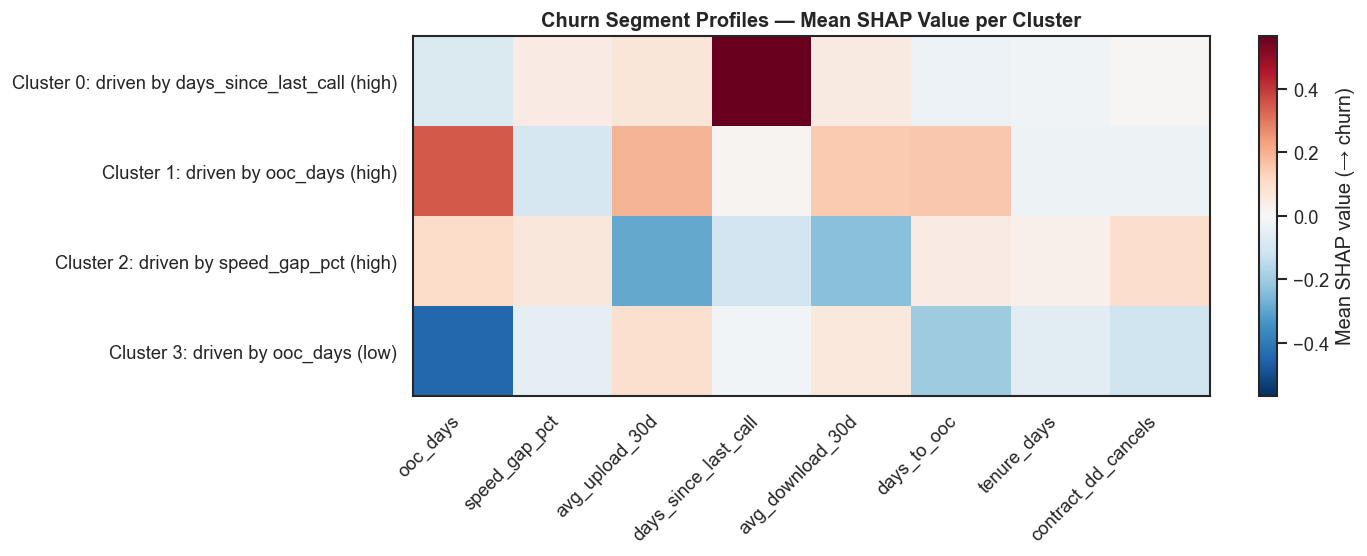

### Actionable Segment Recommendations

| Cluster | Top Driver | Direction | Size | Recommended Action |
|:--------|:-----------|:----------|-----:|:-------------------|
| 0 | **days_since_last_call** | high | 219 | Proactive check-in call (customer has gone quiet) |
| 1 | **ooc_days** | high | 1,456 | Proactive renewal offer 30 days before contract expiry |
| 2 | **speed_gap_pct** | high | 1,894 | Engineering ticket + service credit for underperforming line |
| 3 | **ooc_days** | low | 1,431 | Proactive renewal offer 30 days before contract expiry |

In [10]:
# ── Segment heatmap: mean SHAP per cluster per top feature ────────────────────
TOP_N_HEAT = 8
top_feat_heat_idx = np.argsort(np.abs(shap_values.values).mean(axis=0))[::-1][:TOP_N_HEAT]
top_feat_heat_names = [X_shap.columns[i] for i in top_feat_heat_idx]

heatmap_data = np.zeros((N_CLUSTERS, TOP_N_HEAT))
for cid in range(N_CLUSTERS):
    mask = cluster_ids == cid
    heatmap_data[cid] = shap_values.values[mask][:, top_feat_heat_idx].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, max(4, N_CLUSTERS * 1.2)))
vmax = np.max(np.abs(heatmap_data))
im = ax.imshow(heatmap_data, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Mean SHAP value (→ churn)')

# Auto-labels for row ticks
row_labels = [f"Cluster {s['Cluster']}: driven by {s['Top Driver']} ({s['Direction']})"
              for s in segment_info]
ax.set_yticks(range(N_CLUSTERS))
ax.set_yticklabels(row_labels)
ax.set_xticks(range(TOP_N_HEAT))
ax.set_xticklabels(top_feat_heat_names, rotation=45, ha='right')
ax.set_title('Churn Segment Profiles — Mean SHAP Value per Cluster', fontweight='bold')
plt.tight_layout()
fig.savefig(fig_dir / 'shap_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Actionable insight table (auto-generated, not hardcoded) ──────────────────
from IPython.display import Markdown, display

ACTION_MAP = {
    'ooc_days': 'Proactive renewal offer 30 days before contract expiry',
    'tenure_days': 'Loyalty programme enrolment for long-tenure customers',
    'tenure_log': 'Early-life onboarding programme to reduce new-customer churn',
    'days_since_last_call': 'Proactive check-in call (customer has gone quiet)',
    'speed_gap_pct': 'Engineering ticket + service credit for underperforming line',
    'contract_dd_cancels': 'Payment plan discussion + gentle outreach',
    'total_calls': 'Investigate repeat-contact root cause; warm transfer to specialist',
    'avg_call_duration': 'Review call quality — long calls may indicate unresolved issues',
    'is_out_of_contract': 'Re-contract offer with competitive pricing',
}
DEFAULT_ACTION = 'Investigate further — tailor retention offer based on customer profile'

md_rows = ['| Cluster | Top Driver | Direction | Size | Recommended Action |',
           '|:--------|:-----------|:----------|-----:|:-------------------|']
for s in segment_info:
    action = ACTION_MAP.get(s['Top Driver'], DEFAULT_ACTION)
    md_rows.append(f"| {s['Cluster']} | **{s['Top Driver']}** | {s['Direction']} | {s['Size']:,} | {action} |")

display(Markdown('### Actionable Segment Recommendations\n\n' + '\n'.join(md_rows)))